Universidade do Vale do Itajaí<br>
PPGCA - Programa de Pós-Graduação em Computação Aplicada<br>
Aprendizado Profundo<br>
Prof. Felipe Viel<br>
Conteúdo: Redes Neurais Recorrentes<br>

# Exercício 9: Redes Neurais Recorrentes

Neste exercício você irá utilizar Redes Neurais Recorrentes (RNNs) para trabalhar com dados sequenciais. A atividade foi organizada a partir dos conceitos apresentados na aula de Redes Neurais Recorrentes, incluindo: representação de sequências, RNN, propagação para frente, BPTT, desaparecimento/explosão de gradientes, LSTM, GRU, RNN bidirecional e *word embeddings*.

O problema prático será a classificação de sentimentos no conjunto IMDB. A ideia é começar com uma solução simples e, progressivamente, investigar por que as arquiteturas recorrentes foram propostas e quando arquiteturas com portas, como LSTM e GRU, podem ser vantajosas.

### Objetivos

Ao final, você deverá ser capaz de:

- identificar diferentes tipos de problemas sequenciais;
- explicar a necessidade de memória/estado em uma RNN;
- interpretar as principais equações de uma RNN;
- preparar sequências com vocabulário, índices e *padding*;
- compreender a função da camada `Embedding`;
- implementar `SimpleRNN`, `LSTM`, `GRU` e, opcionalmente, uma RNN bidirecional;
- compreender conceitualmente o BPTT;
- investigar os problemas de *vanishing* e *exploding gradient*;
- comparar desempenho, quantidade de parâmetros e custo computacional;
- justificar a arquitetura final escolhida.

> **Importante:** não procure apenas a maior acurácia. O principal objetivo é relacionar **conceito -> implementação -> experimento -> interpretação**.


<div align="center">

![image-2.png](attachment:image-2.png)

*Exemplos de dados sequenciais apresentados nos slides: voz, música, sentimentos, DNA, tradução e reconhecimento de entidades. — aula sobre Redes Neurais Recorrentes, slide 2.*

</div>

## 1. Dados sequenciais

Uma sequência pode ser representada por

$$X=(x^{\langle1\rangle},x^{\langle2\rangle},\ldots,x^{\langle T_x\rangle}).$$

O índice $t$ representa a posição temporal/seqüencial. Em NLP, por exemplo, $x^{\langle t\rangle}$ pode representar a palavra que aparece na posição $t$.

Nos slides, $T_x$ representa o comprimento da entrada e $T_y$ o comprimento da saída. Esses valores podem ser iguais ou diferentes.

### Tarefa 1

Classifique os problemas abaixo como **many-to-one**, **one-to-many**, **many-to-many com comprimentos iguais** ou **many-to-many com comprimentos diferentes**:

1. Classificação de sentimento de uma frase.
2. Geração de música a partir de uma semente.
3. Reconhecimento de entidade nomeada, atribuindo um rótulo a cada palavra.
4. Tradução automática.
5. Previsão de uma variável a partir de uma janela temporal.

Explique cada resposta.

### Dica

Pergunte: **quantos elementos entram na rede e quantos elementos precisam sair?**


<div align="center">

![image.png](attachment:image.png)

*A aula destaca por que uma rede padrão é inadequada para várias tarefas sequenciais: comprimentos diferentes, dependências de longo prazo e ausência de compartilhamento entre posições. — aula sobre Redes Neurais Recorrentes, slide 6.*

</div>

### Resposta para Tarefa 1

1. Classificação de sentimento de uma frase - many-to-one: Entram vários elementos (palavras da frase) e sai uma única classe, por exemplo, negativo ou positivo

2. Geração de música a partir de uma semente - one-to-many: Uma entrada inicial (semente) é usada para gerar uma sequência de elementos musicais

3. Reconhecimento de entidade nomeada - many-to-many com comprimentos iguais: Há uma saída para cada palavra/token da entrada. Assim, entrada e saída possuem o mesmo comprimento

4. Tradução automática - many-to-many com comprimentos diferentes: Entra uma sequência em um idioma e sai uma sequência em outro idioma. O número de palavras pode ser diferente

5. Previsão de uma variável a partir de uma janela temporal - many-to-one: Vários valores da janela de entrada são utilizados para produzir uma única previsão

Obs: a classificação depende da quantidade de elementos de entrada e de saída, e não simplesmente do fato de o problema ser ou não temporal

## 2. Por que não utilizar simplesmente uma rede Dense?

Uma rede convencional pode receber uma entrada vetorial fixa, mas problemas sequenciais apresentam três dificuldades importantes:

1. **Comprimento variável:** frases diferentes podem ter quantidades diferentes de palavras.
2. **Ordem:** a posição dos elementos pode alterar o significado.
3. **Dependências:** uma decisão em $t$ pode depender de informações que apareceram muito antes.

Além disso, queremos que o mesmo mecanismo seja reutilizado em diferentes posições da sequência. É justamente essa ideia de **compartilhamento de parâmetros ao longo do tempo** que aparece na RNN.

### Tarefa 2

Considere as frases:

- `O filme é bom`
- `O filme não é bom`

Explique por que um modelo que simplesmente agregasse as palavras sem considerar sua ordem poderia ter dificuldade nesse exemplo.


<div align="center">

![image.png](attachment:image.png)

*Propagação para frente de uma RNN desenrolada no tempo, com o estado oculto passando de um instante para o seguinte. — aula sobre Redes Neurais Recorrentes, slide 9.*

</div>

#### Resposta - Tarefa 2

As frases `O filme é bom` e `O filme não é bom` possuem muitas palavras em comum, mas a palavra “não” modifica o significado da frase
   - Se o modelo simplesmente agregasse as palavras e ignorasse a ordem, ele poderia produzir representações muito semelhantes para as duas frases
   - Uma RNN, por outro lado, processa os elementos sequencialmente e mantém um estado oculto. Assim, quando encontra “não”, essa informação pode alterar o estado usado para interpretar as palavras seguintes, especialmente “bom”.

Portanto, a ordem importa porque o significado de um elemento pode depender dos elementos que aparecem antes ou depois dele


## 3. RNN: estado oculto e propagação para frente

A ideia central de uma RNN é manter um estado oculto $a^{\langle t\rangle}$:

$$
a^{\langle t\rangle}=g\left(W_{aa}a^{\langle t-1\rangle}+W_{ax}x^{\langle t\rangle}+b_a\right).
$$

A saída pode ser calculada por:

$$
\hat y^{\langle t\rangle}=g_y\left(W_{ya}a^{\langle t\rangle}+b_y\right).
$$

A forma compacta apresentada na aula é:

$$
a^{\langle t\rangle}=g\left(W_a\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_a\right).
$$

Normalmente, $a^{\langle0\rangle}$ é inicializado com zeros. Os pesos são compartilhados entre os diferentes instantes.

### Tarefa 3 — interpretação da equação

Explique:

1. o papel de $a^{\langle t-1\rangle}$;
2. o papel de $x^{\langle t\rangle}$;
3. o que representa $W_{aa}$;
4. por que o estado pode ser interpretado como uma forma de memória;
5. por que os mesmos pesos são reutilizados em todos os passos.

### Dica

Pense na pergunta: **o que a rede precisa carregar do passado para interpretar a entrada atual?**


### Respostas para Tarefa 3

1.  $a^{\langle t-1\rangle}$ — estado anterior: carrega para o instante atual uma representação das informações relevantes observadas anteriormente.

2. $x^{\langle t\rangle}$ — entrada atual: representa o elemento que está sendo processado no instante `t`.

3. $W_{aa}$ — pesos recorrentes: determinam como o estado anterior influencia o novo estado oculto.

4. Estado como memória: como $a^{\langle t \rangle}$ depende de $a^{\langle t-1\rangle}$, informações dos instantes anteriores podem ser propagadas ao longo da sequência. Por isso o estado funciona como uma forma de memória aprendida.

5. Pesos compartilhados: os mesmos parâmetros são utilizados em todos os instantes. Isso reduz a quantidade de parâmetros e permite aplicar o mesmo mecanismo de processamento independentemente da posição do elemento na sequência.

## 4. Representação das palavras: índice, one-hot e embedding

Os slides apresentam inicialmente uma lista de vocabulário, na qual cada palavra recebe um índice.

Se o vocabulário possui $V$ palavras, uma representação *one-hot* possui dimensão $V$. Para a palavra $w$:

$$o_w\in\mathbb{R}^{V}.$$

Embora simples, essa representação não expressa similaridade semântica: para palavras diferentes, o produto interno entre os vetores *one-hot* é zero.

Com *word embeddings*, cada palavra passa a ser representada por um vetor menor e denso:

$$e_w\in\mathbb{R}^{d}.$$

Se $E$ for a matriz de embeddings:

$$E\in\mathbb{R}^{d\times V},$$

então:

$$e_w=Eo_w.$$

Essa é a formulação apresentada no último slide da aula.

Uma medida comum para comparar embeddings é a similaridade de cosseno:

$$\operatorname{sim}(w_1,w_2)=\frac{e_{w_1}^{T}e_{w_2}}{\|e_{w_1}\|\|e_{w_2}\|}.$$

### Tarefa 4

Explique por que `Embedding` é mais interessante que *one-hot* para alimentar uma RNN.


<div align="center">

![image.png](attachment:image.png)

*A matriz de embeddings apresentada na aula realiza o mapeamento entre uma representação one-hot e um vetor denso de características. — aula sobre Redes Neurais Recorrentes, slide 46.*

</div>

### Respostas para Tarefa 4

Embedding é mais interessante que one-hot porque transforma cada palavra em um vetor denso e de dimensão normalmente muito menor. No one-hot, um vocabulário com V palavras exige vetores de dimensão V, e palavras diferentes são representadas por vetores ortogonais. O modelo não recebe diretamente uma noção de similaridade entre palavras. Com Embedding, cada palavra é mapeada para um vetor de dimensão d, normalmente com d << V. Esses vetores são aprendidos durante o treinamento e podem capturar relações úteis entre palavras. Além disso, para uma RNN, a entrada passa a ter uma representação compacta, reduzindo o custo em relação a alimentar diretamente vetores one-hot de alta dimensão.

## 5. Preparação do conjunto IMDB

Utilizaremos o conjunto IMDB disponível no Keras. Cada avaliação já é fornecida como uma sequência de índices de palavras.

### Como começar

Execute o código e investigue os formatos antes de construir a rede.


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb

print("TensorFlow:", tf.__version__)

NUM_WORDS = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("Primeira sequência:", x_train[0][:20])
print("Classe:", y_train[0])


TensorFlow: 2.20.0


KeyboardInterrupt: 

### Tarefa 5

Determine:

- número de amostras de treinamento e teste;
- valores possíveis de `y_train`;
- tamanho mínimo, máximo, média e mediana das avaliações;
- distribuição dos tamanhos.

### Dica

```python
lengths = np.array([len(x) for x in x_train])
```

Depois utilize `np.min`, `np.max`, `np.mean` e `np.median` e faça um histograma.


In [ ]:
lengths = np.array([len(x) for x in x_train])

print("Mínimo:", np.min(lengths))
print("Máximo:", np.max(lengths))
print("Média:", np.mean(lengths))
print("Mediana:", np.median(lengths))

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50)
plt.xlabel("Número de tokens")
plt.ylabel("Quantidade")
plt.grid()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras.datasets import imdb

print("TensorFlow:", tf.__version__)

NUM_WORDS = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("Primeira sequência:", x_train[0][:20])
print("Classe:", y_train[0])

def plots(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], ".-", label="Train loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], ".-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], ".-", label="Train accuracy")
    if "val_accuracy" in history.history:
        plt.plot(history.history["val_accuracy"], ".-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

def compile_binary(model, learning_rate=1e-3, clipnorm=None):
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm)
    model.compile(optimizer=optimizer, loss="binary_crossentropy",  metrics=["accuracy"])

def train_and_measure(model, epochs=5, batch_size=128):
    start = time.time()
    history = model.fit(x_train_pad, y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
    best_val = max(history.history["val_accuracy"])
    return history, elapsed, test_acc, best_val

In [ ]:
print("Treinamento:", len(x_train))
print("Teste:", len(x_test))
print("Classes:", np.unique(y_train))

lengths = np.array([len(x) for x in x_train])

print("Mínimo:", np.min(lengths))
print("Máximo:", np.max(lengths))
print("Média:", np.mean(lengths))
print("Mediana:", np.median(lengths))

plt.hist(lengths, bins=50)
plt.xlabel("Número de tokens")
plt.ylabel("Quantidade de avaliações")
plt.title("Distribuição do comprimento das avaliações")
plt.show()

In [ ]:
lengths = np.array([len(x) for x in x_train])

print("Mínimo:", np.min(lengths))
print("Máximo:", np.max(lengths))
print("Média:", np.mean(lengths))
print("Mediana:", np.median(lengths))

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50)
plt.xlabel("Número de tokens")
plt.ylabel("Quantidade")
plt.grid()
plt.show()

## 6. Padding e truncamento

Como as sequências têm comprimentos diferentes, vamos utilizar um comprimento máximo $T$.

Após o *padding*, a entrada pode ser vista como:

$$X\in\mathbb{N}^{N\times T},$$

onde $N$ é o número de amostras e $T$ o número máximo de posições temporais.

Se uma sequência for menor que $T$, serão inseridos valores de preenchimento. Se for maior, será truncada.

### Tarefa 6

1. Use inicialmente `MAXLEN = 200`.
2. Repita a preparação para `50`, `100`, `200` e `400`.
3. Discuta o compromisso entre informação preservada e custo computacional.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAXLEN = 200
x_train_pad = pad_sequences(x_train, maxlen=MAXLEN)
x_test_pad = pad_sequences(x_test, maxlen=MAXLEN)

print(x_train_pad.shape)
print(x_test_pad.shape)


### Resposta para Tarefa 6

Os valores MAXLEN = 50, 100, 200 e 400 representam diferentes limites para o comprimento das sequências.

- 50: menor custo computacional, mas maior possibilidade de perder informação de avaliações longas.
- 100: preserva mais contexto, com custo ainda relativamente moderado.
- 200: compromisso intermediário; costuma preservar uma quantidade maior de contexto.
- 400: preserva mais tokens, mas aumenta o custo de processamento e memória.

O ponto importante é que aumentar MAXLEN não garante aumento de desempenho. Se os tokens adicionais não contribuírem para a classificação, o custo aumenta sem benefício proporcional. Uma comparação experimental deve registrar tempo, parâmetros e desempenho para identificar o compromisso adequado ao problema.

# Parte II — Baseline e `SimpleRNN`

## 7. Baseline sem recorrência

Antes de usar uma RNN, precisamos de uma referência. Um baseline simples será:

$$
\text{índices}\rightarrow\text{Embedding}\rightarrow\text{média temporal}\rightarrow\text{Dense}.
$$

A média temporal elimina explicitamente a informação de ordem. Isso permitirá comparar posteriormente o ganho obtido ao introduzir recorrência.

### Como começar

Complete os `...` abaixo.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

def make_baseline():
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        GlobalAveragePooling1D(),
        Dense(1, activation="sigmoid")
    ])
    return model

baseline = make_baseline()
baseline.summary()

### Tarefa 7

Compile e treine o baseline com:

- `binary_crossentropy`;
- Adam;
- `batch_size=128`;
- 5 épocas;
- 20% para validação.

Calcule a acurácia no teste e faça os gráficos de treinamento.

Para classificação binária, a função de perda pode ser escrita como:

$$
L=-[y\log(\hat y)+(1-y)\log(1-\hat y)].
$$


In [ ]:
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_baseline = baseline.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)

print("Teste:", baseline.evaluate(x_test_pad, y_test, verbose=0))


In [ ]:
compile_binary(baseline)

history_baseline = baseline.fit(x_train_pad, y_train, validation_split=0.2, epochs=5,  batch_size=128)

plots(history_baseline)

baseline_loss, baseline_acc = baseline.evaluate(x_test_pad, y_test, verbose=0)

print(f"Acurácia de teste do baseline: {baseline_acc:.4f}")
print(f"Melhor acurácia de validação: {max(history_baseline.history["val_accuracy"]):.4f}")

## 8. `SimpleRNN`

Agora substitua a agregação temporal por uma camada recorrente:

$$
\text{Embedding}\rightarrow\text{SimpleRNN}\rightarrow\text{Dense}.
$$

A `SimpleRNN` implementa a ideia de estado recorrente apresentada nos slides.

### Como começar



In [ ]:
from tensorflow.keras.layers import SimpleRNN

def make_rnn(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        SimpleRNN(units),
        Dense(1, activation="sigmoid")
    ])
    return model

rnn = make_rnn()
rnn.summary()


### Tarefa 8

Treine a `SimpleRNN` nas mesmas condições do baseline e compare:

- acurácia de validação;
- acurácia de teste;
- número de parâmetros;
- tempo de treinamento;
- curvas de `loss` e `accuracy`.

### Perguntas

1. A recorrência melhorou o resultado?
2. Qual informação passou a ser utilizada que não era utilizada pelo baseline?
3. O custo computacional aumentou?
4. Há sinais de overfitting?


### Solução da Tarefa 8

A `SimpleRNN` é treinada nas mesmas condições do baseline. Além da acurácia, registramos o número de parâmetros e o tempo de treinamento.

In [ ]:
compile_binary(rnn)

history_rnn, time_rnn, test_acc_rnn, best_val_rnn = train_and_measure(
    rnn, epochs=5, batch_size=128
)

plots(history_rnn)

print(f"Parâmetros: {rnn.count_params():,}")
print(f"Melhor validação: {best_val_rnn:.4f}")
print(f"Acurácia no teste: {test_acc_rnn:.4f}")
print(f"Tempo de treinamento: {time_rnn:.2f} s")

1. A recorrência melhorou o resultado?: Tem que fazer o experimento, pois depende de tempo, GPU e "vontade".
   
2. Qual informação passou a ser utilizada?: A SimpleRNN passa a utilizar a ordem dos tokens e o estado acumulado da sequência, em vez de tratar a entrada apenas como uma representação sem memória temporal.

3. O custo computacional aumentou?: Em geral, sim, pois a RNN precisa processar os passos sequenciais e possui parâmetros adicionais em relação a um baseline sem recorrência. O tempo medido no notebook deve ser usado para confirmar isso no ambiente utilizado.

4. Há sinais de overfitting?: Como qualquer rede, se a acurácia de treinamento continuar aumentando enquanto a validação piora ou permanece estagnada, e a `val_loss` começar a aumentar, há indícios de overfitting.

## 9. Retropropagação através do tempo — BPTT

No caso de uma RNN, a perda pode ser acumulada ao longo dos passos:

$$
L=\sum_{t=1}^{T_y}L^{\langle t\rangle}.
$$

Durante a retropropagação, o gradiente percorre também as conexões temporais. Esse processo é conhecido como **Backpropagation Through Time (BPTT)**.

A repetição de produtos durante muitos passos ajuda a explicar dois problemas:

- **desaparecimento do gradiente:** fatores menores que 1 podem fazer o gradiente tender rapidamente a zero;
- **explosão do gradiente:** fatores maiores que 1 podem fazer o gradiente crescer muito.

Os slides apresentam *gradient clipping* como uma estratégia prática para a explosão do gradiente.

### Tarefa 9

Explique por que:

$$0.5^{20}\approx9.54\times10^{-7}$$

enquanto

$$1.5^{20}\approx3325.$$

Relacione essa observação com os gradientes em uma RNN.


<div align="center">

![image.png](attachment:image.png)

*O desaparecimento do gradiente é relacionado, na aula, às dependências de longo prazo; LSTM e GRU aparecem como soluções baseadas em unidades com portas. — aula sobre Redes Neurais Recorrentes, slide 20.*

</div>

### Resposta para Tarefa 9

Os valores mostram como pequenas diferenças multiplicadas repetidamente podem produzir efeitos muito grandes:


$$0.5^{20}\approx9.54\times10^{-7}$$
$$1.5^{20}\approx3325.$$


Em uma RNN, durante o BPTT, o gradiente é propagado através de vários passos temporais e envolve repetidas multiplicações por fatores relacionados às derivadas e aos pesos.

- Se esses fatores forem frequentemente menores que 1, o produto pode ficar extremamente pequeno então temos vanishing gradient.
- Se forem maiores que 1, o produto pode crescer muito então temos exploding gradient.

O primeiro caso dificulta que a rede aprenda dependências de longo prazo; o segundo pode tornar a atualização dos pesos instável.

### Tarefa 10 — Gradient clipping

Treine uma configuração da RNN com e sem:

```python
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)
```

Não é necessário provocar uma explosão extrema. O objetivo é entender a técnica e discutir quando ela pode ser útil.


In [ ]:
# Comparação simples: mesma arquitetura, com e sem gradient clipping

rnn_sem_clip = make_rnn()
compile_binary(rnn_sem_clip)

start = time.time()
hist_sem_clip = rnn_sem_clip.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)
tempo_sem_clip = time.time() - start

rnn_clip = make_rnn()
compile_binary(rnn_clip, clipnorm=1.0)

start = time.time()
hist_clip = rnn_clip.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)
tempo_clip = time.time() - start

acc_sem_clip = rnn_sem_clip.evaluate(x_test_pad, y_test, verbose=0)[1]
acc_clip = rnn_clip.evaluate(x_test_pad, y_test, verbose=0)[1]

print("SEM clipping:")
print(f"  melhor validação = {max(hist_sem_clip.history['val_accuracy']):.4f}")
print(f"  teste = {acc_sem_clip:.4f}")
print(f"  tempo = {tempo_sem_clip:.2f} s")

print("\nCOM clipnorm=1.0:")
print(f"  melhor validação = {max(hist_clip.history['val_accuracy']):.4f}")
print(f"  teste = {acc_clip:.4f}")
print(f"  tempo = {tempo_clip:.2f} s")

# Parte III — LSTM

## 10. Long Short-Term Memory

A LSTM adiciona um estado de célula $c^{\langle t\rangle}$ e portas que controlam o fluxo de informação. Os slides descrevem quatro etapas: **Forget → Store → Update → Output**.

A porta de esquecimento é:

$$
\Gamma_f^{\langle t\rangle}=\sigma\left(W_f\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_f\right).
$$

Valores próximos de 0 indicam esquecimento; valores próximos de 1 indicam manutenção.


<div align="center">

![image.png](attachment:image.png)

*Portas da LSTM: a porta de esquecimento controla quanto do estado anterior deve ser mantido. — aula sobre Redes Neurais Recorrentes, slide 23.*

</div>

A LSTM também calcula uma porta de atualização e um candidato:

$$
\Gamma_u^{\langle t\rangle}=\sigma\left(W_u\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_u\right),
$$

$$
\tilde c^{\langle t\rangle}=\tanh\left(W_c\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_c\right).
$$

O estado é atualizado por:

$$
c^{\langle t\rangle}=\Gamma_u^{\langle t\rangle}\odot\tilde c^{\langle t\rangle}+\Gamma_f^{\langle t\rangle}\odot c^{\langle t-1\rangle}.
$$

E a saída:

$$a^{\langle t\rangle}=\Gamma_o^{\langle t\rangle}\odot\tanh(c^{\langle t\rangle}).$$

A ideia não é memorizar tudo, mas aprender **o que preservar, atualizar e expor**.

### Tarefa 11

Associe cada porta à pergunta que ela ajuda a responder:

- Forget
- Update/Store
- Output

Perguntas:

A. O que devo enviar como estado oculto?

B. O que devo manter do passado?

C. Que informação nova devo incorporar?


In [ ]:
from tensorflow.keras.layers import LSTM

def make_lstm(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        LSTM(units),
        Dense(1, activation="sigmoid")
    ])
    return model

lstm = make_lstm()
lstm.summary()


### Resposta para Tarefa 11

A associação correta é:

- Forget (B). O que devo manter do passado?
- Update/Store (C). Que informação nova devo incorporar?
- Output (A). O que devo enviar como estado oculto?

A ideia central da LSTM é controlar explicitamente o fluxo de informação. As portas utilizam funções como a sigmoide para produzir valores entre 0 e 1, funcionando como mecanismos aprendidos de controle.

### Tarefa 12 — SimpleRNN × LSTM

Treine a LSTM mantendo constantes, tanto quanto possível, `MAXLEN`, dimensão do embedding, número de unidades, batch size, taxa de aprendizado e número de épocas.

Compare:

- parâmetros;
- tempo;
- melhor validação;
- teste;
- curvas.

**Conclusão:** o aumento de complexidade compensou? Justifique usando os seus resultados.


In [ ]:
from tensorflow.keras.layers import LSTM

def make_lstm(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        LSTM(units),
        Dense(1, activation="sigmoid")
    ])
    return model

lstm = make_lstm()
lstm.summary()

In [ ]:
compile_binary(lstm)

history_lstm, time_lstm, test_acc_lstm, best_val_lstm = train_and_measure(
    lstm, epochs=5, batch_size=128
)

plots(history_lstm)

print(f"Parâmetros: {lstm.count_params():,}")
print(f"Melhor validação: {best_val_lstm:.4f}")
print(f"Acurácia no teste: {test_acc_lstm:.4f}")
print(f"Tempo de treinamento: {time_lstm:.2f} s")

In [ ]:
resultados_rnn_lstm = [
    ["SimpleRNN", rnn.count_params(), time_rnn, best_val_rnn, test_acc_rnn],
    ["LSTM", lstm.count_params(), time_lstm, best_val_lstm, test_acc_lstm],
]

print(f"{'Modelo':<15}{'Parâmetros':>15}{'Tempo (s)':>15}{'Val. melhor':>15}{'Teste':>12}")
for nome, params, tempo, val, teste in resultados_rnn_lstm:
    print(f"{nome:<15}{params:>15,}{tempo:>15.2f}{val:>15.4f}{teste:>12.4f}")

### Resolução para Tarefa 12

A comparação deve manter constantes, tanto quanto possível, MAXLEN, embedding, número de unidades, batch size, learning rate e épocas.

Quando for analisar, você deve olhar (pois professor executar pode ser diferente do aluno):

- Parâmetros: a LSTM normalmente possui mais parâmetros que uma SimpleRNN equivalente porque utiliza múltiplos conjuntos de pesos associados às suas portas.
- Tempo: a LSTM pode exigir mais operações por passo.
- Validação e teste: devem ser obtidos experimentalmente.
- Curvas: observe estabilidade e sinais de overfitting.

Conclusão: não é correto concluir apenas pela complexidade teórica. A justificativa deve relacionar o ganho observado nos resultados com o aumento de custo da arquitetura.

# Parte IV — GRU

## 11. Gated Recurrent Unit

A GRU também utiliza portas, mas possui uma estrutura mais compacta. Nos slides aparecem as portas **reset** e **update**.

A porta de reset é:

$$
\Gamma_r^{\langle t\rangle}=\sigma\left(W_r\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_r\right).
$$

A porta de atualização é:

$$
\Gamma_u^{\langle t\rangle}=\sigma\left(W_u\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_u\right).
$$

Uma forma equivalente à apresentada na aula é:

$$
\tilde c^{\langle t\rangle}=\tanh\left(W_c\begin{bmatrix}\Gamma_r^{\langle t\rangle}\odot c^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_c\right),
$$

$$
c^{\langle t\rangle}=\Gamma_u^{\langle t\rangle}\odot\tilde c^{\langle t\rangle}+(1-\Gamma_u^{\langle t\rangle})\odot c^{\langle t-1\rangle}.
$$


<div align="center">

![image.png](attachment:image.png)

*A GRU utiliza portas de reset e atualização para controlar a contribuição do estado anterior e do novo candidato. — aula sobre Redes Neurais Recorrentes, slide 30.*

</div>

In [ ]:
from tensorflow.keras.layers import GRU

def make_gru(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        GRU(units),
        Dense(1, activation="sigmoid")
    ])
    return model

gru = make_gru()
gru.summary()


### Tarefa 13 — SimpleRNN × LSTM × GRU

Treine as três arquiteturas sob condições comparáveis.

Monte uma tabela e discuta:

1. Qual teve melhor desempenho?
2. Quem tem mais parâmetros
3. Qual teve menor complexidade?
4. Qual foi mais rápido?
5. Houve uma diferença suficientemente grande para justificar uma arquitetura mais complexa?


In [ ]:
from tensorflow.keras.layers import GRU

def make_gru(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        GRU(units),
        Dense(1, activation="sigmoid")
    ])
    return model

gru = make_gru()
gru.summary()

In [ ]:
compile_binary(gru)

history_gru, time_gru, test_acc_gru, best_val_gru = train_and_measure(
    gru, epochs=5, batch_size=128
)

plots(history_gru)

print(f"Parâmetros: {gru.count_params():,}")
print(f"Melhor validação: {best_val_gru:.4f}")
print(f"Acurácia no teste: {test_acc_gru:.4f}")
print(f"Tempo de treinamento: {time_gru:.2f} s")

In [ ]:
resultados = [
    ["SimpleRNN", rnn.count_params(), time_rnn, best_val_rnn, test_acc_rnn],
    ["LSTM", lstm.count_params(), time_lstm, best_val_lstm, test_acc_lstm],
    ["GRU", gru.count_params(), time_gru, best_val_gru, test_acc_gru],
]

print(f"{'Modelo':<15}{'Parâmetros':>15}{'Tempo (s)':>15}{'Val. melhor':>15}{'Teste':>12}")
for nome, params, tempo, val, teste in resultados:
    print(f"{nome:<15}{params:>15,}{tempo:>15.2f}{val:>15.4f}{teste:>12.4f}")

print("\nObservação: os resultados acima são experimentais. A comparação deve considerar")
print("desempenho, número de parâmetros e tempo, e não apenas uma única métrica.")


# Parte V — Bidirectional e Deep RNN

## 12. RNN bidirecional

Uma RNN convencional usa principalmente o contexto anterior. Uma **Bidirectional RNN** processa a sequência nas duas direções e combina as informações.

Isso é útil quando o elemento atual pode ser melhor interpretado usando também palavras posteriores. Porém, a principal limitação apresentada nos slides é que a sequência completa precisa estar disponível antes do processamento. fileciteturn3file0L408-L423


<div align="center">

![image.png](attachment:image.png)

*A BRNN utiliza ativações das duas direções; a aula destaca como desvantagem a necessidade de conhecer a sequência completa. — aula sobre Redes Neurais Recorrentes, slide 33.*

</div>

In [ ]:
from tensorflow.keras.layers import Bidirectional

def make_bilstm(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        Bidirectional(LSTM(units)),
        Dense(1, activation="sigmoid")
    ])
    return model

bilstm = make_bilstm()
bilstm.summary()


### Tarefa 14 — Bidirecionalidade

Treine a BiLSTM e compare com a LSTM unidirecional.

Responda:

1. Quantos parâmetros adicionais surgiram?
2. O desempenho melhorou?
3. A utilização de contexto futuro é válida em classificação de uma frase inteira?
4. Seria válida em uma aplicação de previsão em tempo real? Justifique.


In [ ]:
compile_binary(bilstm)

history_bilstm, time_bilstm, test_acc_bilstm, best_val_bilstm = train_and_measure(
    bilstm, epochs=5, batch_size=128
)

plots(history_bilstm)

print(f"Parâmetros: {bilstm.count_params():,}")
print(f"Melhor validação: {best_val_bilstm:.4f}")
print(f"Acurácia no teste: {test_acc_bilstm:.4f}")
print(f"Tempo de treinamento: {time_bilstm:.2f} s")

#### Resposta para questionamentos:

Parâmetros: A BiLSTM possui duas LSTMs, aumentando a quantidade de parâmetros. No modelo utilizado, são 16.384 parâmetros adicionais em relação à LSTM unidirecional.

Desempenho: Deve ser determinado pelos resultados experimentais de acurácia, validação e tempo. Maior complexidade não garante necessariamente maior desempenho.

Classificação de frase inteira: Sim. Como a frase completa está disponível antes da classificação, é válido utilizar contexto anterior e posterior.

Previsão em tempo real: Não, em geral. A BiLSTM utiliza informações futuras, que podem ainda não estar disponíveis no momento da previsão. Para aplicações online, uma LSTM unidirecional é mais apropriada.

## 13. Deep RNN

É possível empilhar camadas recorrentes. Para isso, uma camada intermediária precisa retornar **toda a sequência**:

```python
SimpleRNN(64, return_sequences=True)
```

A camada seguinte recebe então uma sequência, e não apenas o estado final.

Os slides também apresentam o conceito de **Deep RNN**, com várias camadas recorrentes empilhadas. fileciteturn3file0L426-L432


In [ ]:
def make_deep_rnn(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        SimpleRNN(units, return_sequences=True),
        SimpleRNN(units),
        Dense(1, activation="sigmoid")
    ])
    return model

deep_rnn = make_deep_rnn()
deep_rnn.summary()


### Tarefa 15

Compare uma `SimpleRNN` com a versão profunda.

Explique por que `return_sequences=True` é necessário na primeira camada recorrente.


### Resposta para Tarefa 15

`return_sequences=True` faz a camada recorrente retornar o estado/saída de cada passo temporal, e não somente o último estado. Uma segunda camada recorrente precisa receber uma sequência com formato semelhante a:

```text
(batch, tempo, características)
```

Se a primeira RNN retornar somente o último estado, a saída perde a dimensão temporal e não poderá ser interpretada pela segunda RNN como uma sequência completa. Por isso, ao empilhar RNNs, normalmente utilizamos:

```python
layers.SimpleRNN(units, return_sequences=True),
layers.SimpleRNN(units)
```

A primeira produz uma sequência; a última pode produzir somente o estado final para a classificação.

# Parte VI — Experimento sistemático

## 14. Efeito do tamanho da sequência

Escolha LSTM ou GRU e compare:

```text
MAXLEN = 50, 100, 200, 400
```

Para cada configuração, registre:

- número de parâmetros;
- tempo de treinamento;
- melhor acurácia de validação;
- acurácia no teste.

### Tarefa 16

Produza:

1. tabela de resultados;
2. gráfico de acurácia × `MAXLEN`;
3. gráfico de tempo × `MAXLEN`;
4. conclusão sobre o melhor compromisso entre informação e custo.

> Não reutilize os pesos de um modelo quando mudar `MAXLEN`: crie e treine um novo modelo.


### Respostas para Tarefa 16

A tabela final deve ser construída com os resultados experimentais para cada MAXLEN.

In [ ]:
# Exemplo de estrutura:
'''
resultados_maxlen = pd.DataFrame({
    "MAXLEN": [50, 100, 200, 400],
    "Parâmetros": [None, None, None, None],
    "Tempo_s": [None, None, None, None],
    "Val_acc": [None, None, None, None],
    "Test_acc": [None, None, None, None],
})
'''

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


#Configurações do experimento

MAXLENS = [50, 100, 200, 400]

EPOCHS = 5
BATCH_SIZE = 128
UNITS = 64
EMBEDDING_DIM = 32


#Função para criar o modelo
# Um novo modelo é criado para cada MAXLEN.
# O MAXLEN não entra diretamente na arquitetura, mas altera
# o tamanho das sequências utilizadas durante o treinamento.

def criar_modelo_lstm():
    model = Sequential([
        Embedding(
            input_dim=NUM_WORDS,
            output_dim=EMBEDDING_DIM
        ),

        LSTM(UNITS),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


#Executar o experimento
resultados = []

for maxlen in MAXLENS:
    print("=" * 60)
    print(f"Treinando modelo com MAXLEN = {maxlen}")
    print("=" * 60)

    # Criar novas sequências
    X_train_max = pad_sequences(x_train, maxlen=maxlen)
    X_test_max = pad_sequences(x_test, maxlen=maxlen)

    # Criar NOVO modelo
    model = criar_modelo_lstm()

    # Construir o modelo usando o formato da entrada
    model.build(input_shape=(None, maxlen))

    print(f"\nNúmero de parâmetros: {model.count_params():,}")

    #Treinamento
    inicio = time.time()

    history = model.fit(X_train_max, y_train, validation_split=0.2, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1    )

    tempo_treinamento = time.time() - inicio

    #Avaliação no conjunto de teste
    loss, test_acc = model.evaluate(
        X_test_max,
        y_test,
        verbose=0
    )

    # Melhor acurácia de validação
    best_val_acc = max(history.history["val_accuracy"])

    #Armazenar resultados
    resultados.append({
        "MAXLEN": maxlen,
        "Parâmetros": model.count_params(),
        "Tempo_s": tempo_treinamento,
        "Val_acc": best_val_acc,
        "Test_acc": test_acc
    })

    print(f"\nMAXLEN: {maxlen}")
    print(f"Parâmetros: {model.count_params():,}")
    print(f"Melhor validação: {best_val_acc:.4f}")
    print(f"Acurácia teste: {test_acc:.4f}")
    print(f"Tempo: {tempo_treinamento:.2f} s")


#Criar tabela final
resultados_maxlen = pd.DataFrame(resultados)

resultados_maxlen

In [ ]:
#ACURÁCIA × MAXLEN

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_maxlen["MAXLEN"],
    resultados_maxlen["Val_acc"],
    marker="o",
    label="Validação"
)

plt.plot(
    resultados_maxlen["MAXLEN"],
    resultados_maxlen["Test_acc"],
    marker="o",
    label="Teste"
)

plt.xlabel("MAXLEN")
plt.ylabel("Acurácia")
plt.title("Acurácia × MAXLEN")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#TEMPO × MAXLEN


plt.figure(figsize=(8, 5))

plt.plot(
    resultados_maxlen["MAXLEN"],
    resultados_maxlen["Tempo_s"],
    marker="o"
)

plt.xlabel("MAXLEN")
plt.ylabel("Tempo de treinamento (s)")
plt.title("Tempo de treinamento × MAXLEN")

plt.grid(True)

plt.show()

In [ ]:
#TABELA FORMATADA

tabela = resultados_maxlen.copy()

tabela["Tempo_s"] = tabela["Tempo_s"].round(2)

tabela["Val_acc"] = (
    tabela["Val_acc"] * 100
).round(2)

tabela["Test_acc"] = (
    tabela["Test_acc"] * 100
).round(2)

tabela.columns = [
    "MAXLEN",
    "Parâmetros",
    "Tempo (s)",
    "Validação (%)",
    "Teste (%)"
]

tabela

In [ ]:
#ANÁLISE

melhor_teste = resultados_maxlen.loc[
    resultados_maxlen["Test_acc"].idxmax()
]

menor_tempo = resultados_maxlen.loc[
    resultados_maxlen["Tempo_s"].idxmin()
]

print("Melhor acurácia no teste:")
print(
    f"MAXLEN = {int(melhor_teste['MAXLEN'])} | "
    f"Acurácia = {melhor_teste['Test_acc']:.4f}"
)

print("\nMenor tempo de treinamento:")
print(
    f"MAXLEN = {int(menor_tempo['MAXLEN'])} | "
    f"Tempo = {menor_tempo['Tempo_s']:.2f} s"
)

## 15. Efeito da dimensão do embedding

Repita um experimento com:

```text
embedding_dim = 16, 32, 64, 128
```

A matriz de embeddings possui aproximadamente:

$$V\times d$$

parâmetros.

### Tarefa 17

Investigue como o aumento de $d$ altera:

- número de parâmetros;
- tempo;
- acurácia;
- overfitting.

Explique por que o número de parâmetros cresce com a dimensão do embedding.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Definir o tamanho das sequências
MAXLEN = 200

# Criar os conjuntos com padding
X_train = pad_sequences(
    x_train,
    maxlen=MAXLEN
)

X_test = pad_sequences(
    x_test,
    maxlen=MAXLEN
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

In [85]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


#Configurações do experimento


EMBEDDING_DIMS = [16, 32, 64, 128]

UNITS = 64
EPOCHS = 5
BATCH_SIZE = 128


#Função para criar o modelo

def criar_modelo_embedding(embedding_dim):

    model = Sequential([
        Embedding(
            input_dim=NUM_WORDS,
            output_dim=embedding_dim
        ),

        LSTM(UNITS),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


#Executar os experimentos

resultados_embedding = []

historicos_embedding = {}

for embedding_dim in EMBEDDING_DIMS:

    print("=" * 60)
    print(f"Treinando com embedding_dim = {embedding_dim}")
    print("=" * 60)

    #Criar NOVO modelo

    model = criar_modelo_embedding(embedding_dim)

    model.build(input_shape=(None, X_train.shape[1]))

    parametros = model.count_params()

    print(f"Parâmetros: {parametros:,}")

    #Treinamento

    inicio = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    tempo = time.time() - inicio

    #Avaliação

    loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # Melhor acurácia de validação
    best_val_acc = max(
        history.history["val_accuracy"]
    )

    # Acurácia de treinamento na última época
    final_train_acc = history.history["accuracy"][-1]

    # Acurácia de validação na última época
    final_val_acc = history.history["val_accuracy"][-1]

    #Armazenar histórico

    historicos_embedding[embedding_dim] = history

    #Armazenar resultados

    resultados_embedding.append({
        "Embedding_dim": embedding_dim,
        "Parâmetros": parametros,
        "Tempo_s": tempo,
        "Melhor_Val_acc": best_val_acc,
        "Test_acc": test_acc,
        "Train_acc_final": final_train_acc,
        "Val_acc_final": final_val_acc
    })

    print(f"\nEmbedding: {embedding_dim}")
    print(f"Parâmetros: {parametros:,}")
    print(f"Tempo: {tempo:.2f} s")
    print(f"Melhor validação: {best_val_acc:.4f}")
    print(f"Acurácia teste: {test_acc:.4f}")

Treinando com embedding_dim = 16
Parâmetros: 180,801
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7399 - loss: 0.5087 - val_accuracy: 0.8638 - val_loss: 0.3197
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8892 - loss: 0.2783 - val_accuracy: 0.8536 - val_loss: 0.3439
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9235 - loss: 0.2032 - val_accuracy: 0.8768 - val_loss: 0.3039
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9464 - loss: 0.1552 - val_accuracy: 0.8744 - val_loss: 0.3238
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9578 - loss: 0.1234 - val_accuracy: 0.8620 - val_loss: 0.3334

Embedding: 16
Parâmetros: 180,801
Tempo: 11.46 s
Melhor validação: 0.8768
Acurácia teste: 0.8588
Treinando com embedding_dim = 32
Parâmetros: 344,897
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7621 - loss: 0.4806 - val_accuracy: 0.8608 - val_loss: 0.3447
Epoch 2/5
157/157 ━━━━━━━━━━

In [87]:
#TABELA FINAL

resultados_embedding = pd.DataFrame(
    resultados_embedding
)

resultados_embedding

,Embedding_dim,Parâmetros,Tempo_s,Melhor_Val_acc,Test_acc,Train_acc_final,Val_acc_final
0,16,180801,11.462989,0.8768,0.85884,0.95780,0.8620
1,32,344897,11.423103,0.8748,0.83760,0.95845,0.8572
2,64,673089,11.464851,0.8734,0.86104,0.96095,0.8704
3,128,1329473,11.386695,0.8766,0.85484,0.96940,0.8602


In [88]:
#TABELA FORMATADA

tabela_embedding = resultados_embedding.copy()

tabela_embedding["Tempo_s"] = (
    tabela_embedding["Tempo_s"].round(2)
)

tabela_embedding["Melhor_Val_acc"] = (
    tabela_embedding["Melhor_Val_acc"] * 100
).round(2)

tabela_embedding["Test_acc"] = (
    tabela_embedding["Test_acc"] * 100
).round(2)

tabela_embedding["Train_acc_final"] = (
    tabela_embedding["Train_acc_final"] * 100
).round(2)

tabela_embedding["Val_acc_final"] = (
    tabela_embedding["Val_acc_final"] * 100
).round(2)

tabela_embedding

,Embedding_dim,Parâmetros,Tempo_s,Melhor_Val_acc,Test_acc,Train_acc_final,Val_acc_final
0,16,180801,11.46,87.68,85.88,95.78,86.20
1,32,344897,11.42,87.48,83.76,95.85,85.72
2,64,673089,11.46,87.34,86.10,96.10,87.04
3,128,1329473,11.39,87.66,85.48,96.94,86.02


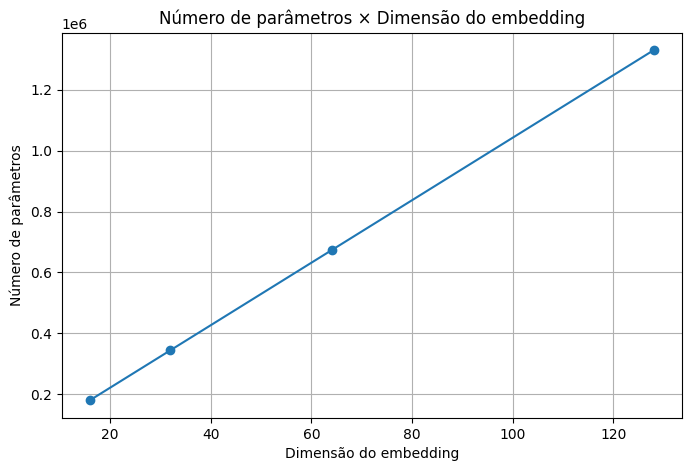

In [89]:
#PARÂMETROS × EMBEDDING

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_embedding["Embedding_dim"],
    resultados_embedding["Parâmetros"],
    marker="o"
)

plt.xlabel("Dimensão do embedding")
plt.ylabel("Número de parâmetros")
plt.title("Número de parâmetros × Dimensão do embedding")

plt.grid(True)

plt.show()

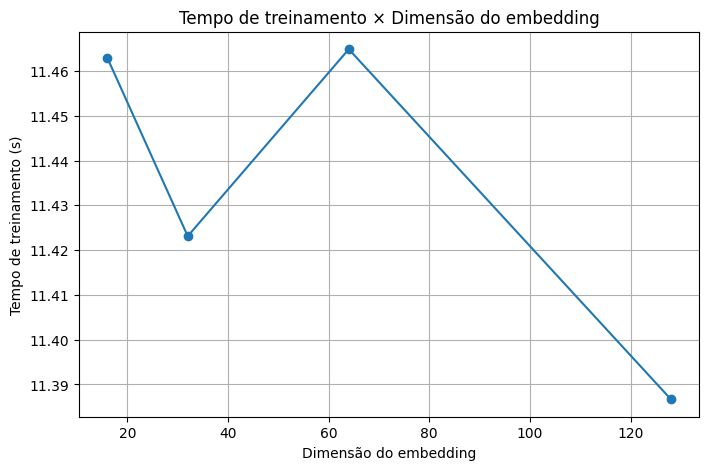

In [90]:
#TEMPO × EMBEDDING

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_embedding["Embedding_dim"],
    resultados_embedding["Tempo_s"],
    marker="o"
)

plt.xlabel("Dimensão do embedding")
plt.ylabel("Tempo de treinamento (s)")
plt.title("Tempo de treinamento × Dimensão do embedding")

plt.grid(True)

plt.show()

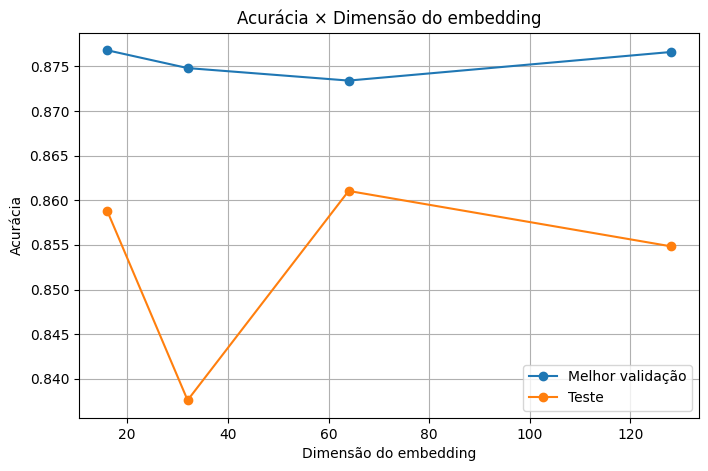

In [91]:
#ACURÁCIA × EMBEDDING

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_embedding["Embedding_dim"],
    resultados_embedding["Melhor_Val_acc"],
    marker="o",
    label="Melhor validação"
)

plt.plot(
    resultados_embedding["Embedding_dim"],
    resultados_embedding["Test_acc"],
    marker="o",
    label="Teste"
)

plt.xlabel("Dimensão do embedding")
plt.ylabel("Acurácia")
plt.title("Acurácia × Dimensão do embedding")

plt.legend()
plt.grid(True)

plt.show()

In [92]:
#ANÁLISE DE OVERFITTING

for embedding_dim, history in historicos_embedding.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    gap = train_acc - val_acc

    print(
        f"Embedding {embedding_dim:3d} | "
        f"Train: {train_acc:.4f} | "
        f"Val: {val_acc:.4f} | "
        f"Gap: {gap:.4f}"
    )

Embedding  16 | Train: 0.9578 | Val: 0.8620 | Gap: 0.0958
Embedding  32 | Train: 0.9585 | Val: 0.8572 | Gap: 0.1012
Embedding  64 | Train: 0.9610 | Val: 0.8704 | Gap: 0.0906
Embedding 128 | Train: 0.9694 | Val: 0.8602 | Gap: 0.1092


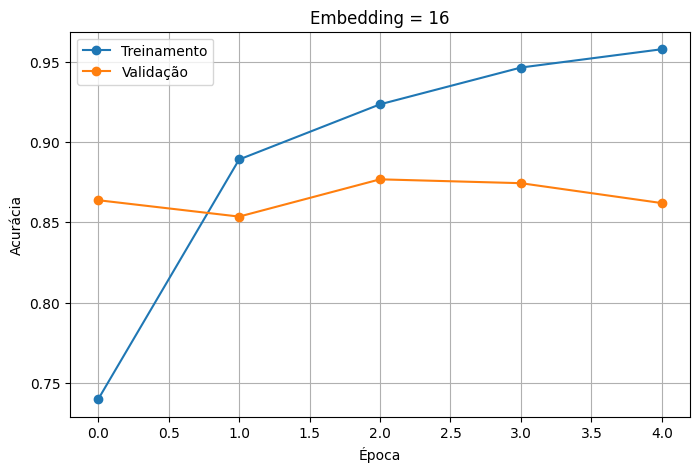

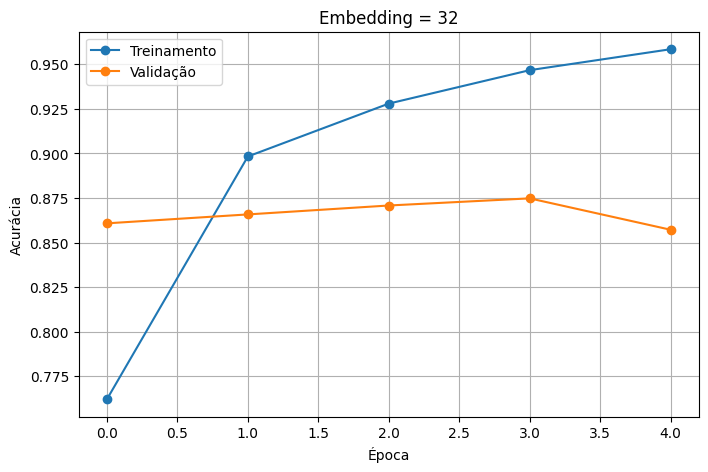

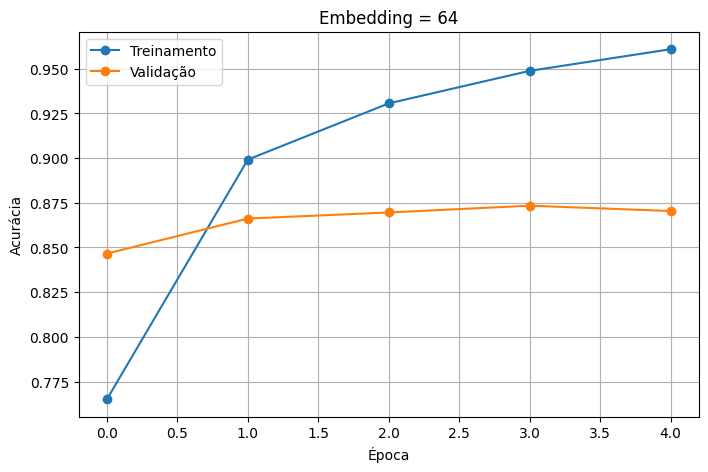

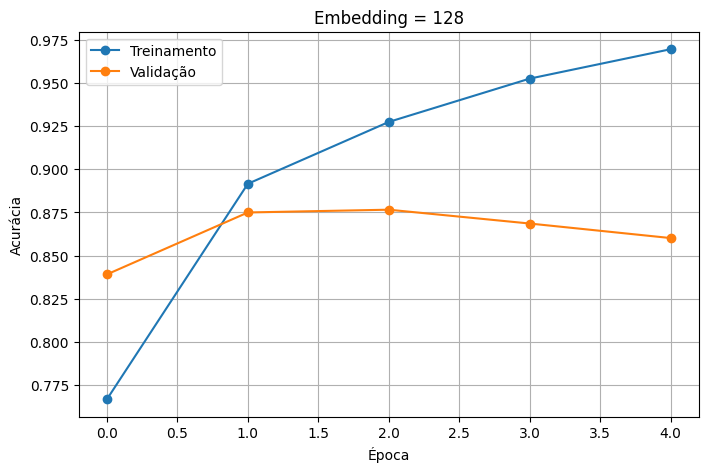

In [93]:
#CURVAS DE TREINAMENTO

for embedding_dim, history in historicos_embedding.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label="Treinamento"
    )

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label="Validação"
    )

    plt.xlabel("Época")
    plt.ylabel("Acurácia")

    plt.title(
        f"Embedding = {embedding_dim}"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [94]:
#RESUMO DO EXPERIMENTO

maior_acuracia = resultados_embedding.loc[
    resultados_embedding["Test_acc"].idxmax()
]

menor_tempo = resultados_embedding.loc[
    resultados_embedding["Tempo_s"].idxmin()
]

maior_modelo = resultados_embedding.loc[
    resultados_embedding["Parâmetros"].idxmax()
]

print("Maior acurácia no teste:")
print(
    f"Embedding = {int(maior_acuracia['Embedding_dim'])} | "
    f"Acurácia = {maior_acuracia['Test_acc']:.4f}"
)

print("\nMenor tempo:")
print(
    f"Embedding = {int(menor_tempo['Embedding_dim'])} | "
    f"Tempo = {menor_tempo['Tempo_s']:.2f} s"
)

print("\nMaior número de parâmetros:")
print(
    f"Embedding = {int(maior_modelo['Embedding_dim'])} | "
    f"Parâmetros = {int(maior_modelo['Parâmetros']):,}"
)

Maior acurácia no teste:
Embedding = 64 | Acurácia = 0.8610

Menor tempo:
Embedding = 128 | Tempo = 11.39 s

Maior número de parâmetros:
Embedding = 128 | Parâmetros = 1,329,473


d = 16 -> matriz de embedding aproximadamente V × 16

d = 32 -> aproximadamente V × 32

d = 64 -> aproximadamente V × 64

d = 128 -> aproximadamente V × 128

Portanto, mantendo o vocabulário V constante, dobrar a dimensão do embedding aproximadamente dobra os parâmetros da matriz de embeddings.

O aumento de d também pode aumentar a capacidade de representação, mas traz maior custo de memória e computação e pode facilitar overfitting, especialmente quando os dados são limitados. A conclusão deve ser baseada nos quatro indicadores solicitados: parâmetros, tempo, acurácia e overfitting.

## 16. Modelo final

Escolha a configuração que você considera mais adequada e faça um treinamento final.

Você pode alterar:

- `MAXLEN`;
- embedding dimension;
- número de unidades;
- SimpleRNN/LSTM/GRU;
- número de camadas;
- dropout;
- learning rate;
- batch size.

### Recomendação

Use `EarlyStopping` para evitar treinamento desnecessário:

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
```

Registre a **hipótese** antes de cada alteração importante. Por exemplo:

> "Aumentar o embedding de 32 para 64 pode melhorar a representação sem aumentar excessivamente o custo."


In [95]:
#TAREFA 16 — MODELO FINAL

import time
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


#Configuração escolhida
# Ajuste estes valores com base nos experimentos anteriores.

FINAL_MAXLEN = 200
FINAL_EMBEDDING_DIM = 32
FINAL_UNITS = 64
FINAL_DROPOUT = 0.2

FINAL_EPOCHS = 10
FINAL_BATCH_SIZE = 128
FINAL_LEARNING_RATE = 0.001


#Preparar os dados

x_train_final = pad_sequences(
    X_train,
    maxlen=FINAL_MAXLEN
)

x_test_final = pad_sequences(
    X_test,
    maxlen=FINAL_MAXLEN
)


print("Formato dos dados de treinamento:")
print(x_train_final.shape)

print("\nFormato dos dados de teste:")
print(x_test_final.shape)

Formato dos dados de treinamento:
(25000, 200)

Formato dos dados de teste:
(25000, 200)


In [96]:
#CRIAÇÃO DO MODELO FINAL

final_model = Sequential([

    Embedding(
        input_dim=NUM_WORDS,
        output_dim=FINAL_EMBEDDING_DIM
    ),

    LSTM(
        FINAL_UNITS,
        dropout=FINAL_DROPOUT
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


#Compilação
optimizer = tf.keras.optimizers.Adam(
    learning_rate=FINAL_LEARNING_RATE
)

final_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


#Resumo da arquitetura
final_model.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [97]:
#EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [98]:
#TREINAMENTO FINAL
inicio = time.time()

history_final = final_model.fit(
    x_train_final,
    y_train,

    validation_split=0.2,

    epochs=FINAL_EPOCHS,

    batch_size=FINAL_BATCH_SIZE,

    callbacks=[early_stop],

    verbose=1
)

tempo_final = time.time() - inicio


print("\n" + "=" * 50)
print("TREINAMENTO FINALIZADO")
print("=" * 50)

print(f"Tempo de treinamento: {tempo_final:.2f} s")
print(f"Épocas executadas: {len(history_final.history['loss'])}")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7504 - loss: 0.4926 - val_accuracy: 0.8690 - val_loss: 0.3216
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8927 - loss: 0.2714 - val_accuracy: 0.8668 - val_loss: 0.3174
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9237 - loss: 0.2027 - val_accuracy: 0.8798 - val_loss: 0.3096
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9381 - loss: 0.1718 - val_accuracy: 0.8724 - val_loss: 0.3188
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9491 - loss: 0.1420 - val_accuracy: 0.8598 - val_loss: 0.3479

TREINAMENTO FINALIZADO
Tempo de treinamento: 13.19 s
Épocas executadas: 5


In [99]:
#AVALIAÇÃO FINAL

final_loss, final_acc = final_model.evaluate(
    x_test_final,
    y_test,
    verbose=0
)

best_val_acc = max(
    history_final.history["val_accuracy"]
)

print("=" * 50)
print("RESULTADOS DO MODELO FINAL")
print("=" * 50)

print(f"Parâmetros: {final_model.count_params():,}")
print(f"Melhor acurácia de validação: {best_val_acc:.4f}")
print(f"Acurácia no teste: {final_acc:.4f}")
print(f"Loss no teste: {final_loss:.4f}")
print(f"Tempo de treinamento: {tempo_final:.2f} s")

RESULTADOS DO MODELO FINAL
Parâmetros: 344,897
Melhor acurácia de validação: 0.8798
Acurácia no teste: 0.8690
Loss no teste: 0.3291
Tempo de treinamento: 13.19 s


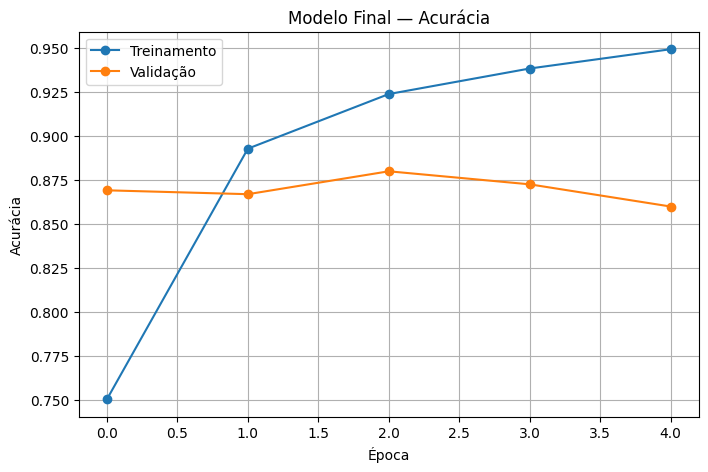

In [100]:
#CURVAS DE TREINAMENTO

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["accuracy"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    history_final.history["val_accuracy"],
    marker="o",
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Modelo Final — Acurácia")

plt.legend()
plt.grid(True)

plt.show()

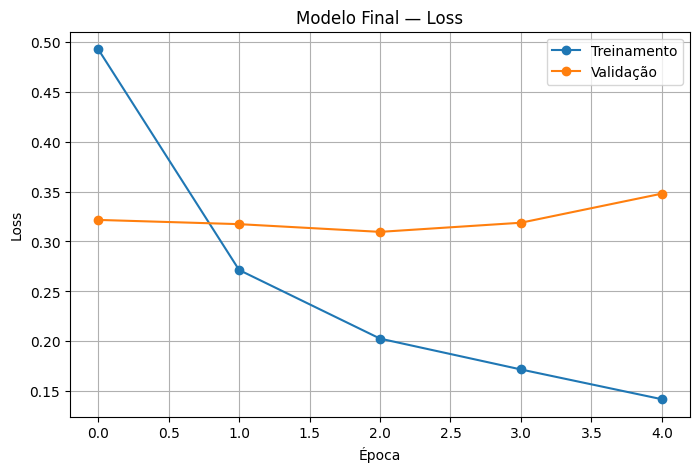

In [101]:
#CURVA DE LOSS

plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["loss"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    history_final.history["val_loss"],
    marker="o",
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Modelo Final — Loss")

plt.legend()
plt.grid(True)

plt.show()

In [102]:
#REGISTRO DA CONFIGURAÇÃO FINAL

print("=" * 60)
print("CONFIGURAÇÃO DO MODELO FINAL")
print("=" * 60)

print(f"MAXLEN:              {FINAL_MAXLEN}")
print(f"Embedding:           {FINAL_EMBEDDING_DIM}")
print(f"Unidades LSTM:       {FINAL_UNITS}")
print(f"Dropout:             {FINAL_DROPOUT}")
print(f"Learning rate:       {FINAL_LEARNING_RATE}")
print(f"Batch size:          {FINAL_BATCH_SIZE}")
print(f"Épocas máximas:      {FINAL_EPOCHS}")
print(f"Épocas executadas:   {len(history_final.history['loss'])}")

print("\nRESULTADOS")
print("-" * 60)

print(f"Parâmetros:           {final_model.count_params():,}")
print(f"Melhor Val Accuracy:  {best_val_acc:.4f}")
print(f"Test Accuracy:        {final_acc:.4f}")
print(f"Test Loss:            {final_loss:.4f}")
print(f"Tempo:                {tempo_final:.2f} s")

CONFIGURAÇÃO DO MODELO FINAL
MAXLEN:              200
Embedding:           32
Unidades LSTM:       64
Dropout:             0.2
Learning rate:       0.001
Batch size:          128
Épocas máximas:      10
Épocas executadas:   5

RESULTADOS
------------------------------------------------------------
Parâmetros:           344,897
Melhor Val Accuracy:  0.8798
Test Accuracy:        0.8690
Test Loss:            0.3291
Tempo:                13.19 s


# Parte VII — Avaliação

## 17. Matriz de confusão e análise de erros

Para o modelo final, apresente:

- `model.summary()`;
- número de parâmetros;
- melhor acurácia de validação;
- acurácia no teste;
- curvas de treinamento;
- matriz de confusão;
- pelo menos 5 exemplos classificados incorretamente.

Para classificação binária:

$$
CM=\begin{bmatrix}TN&FP\\FN&TP\end{bmatrix}.
$$


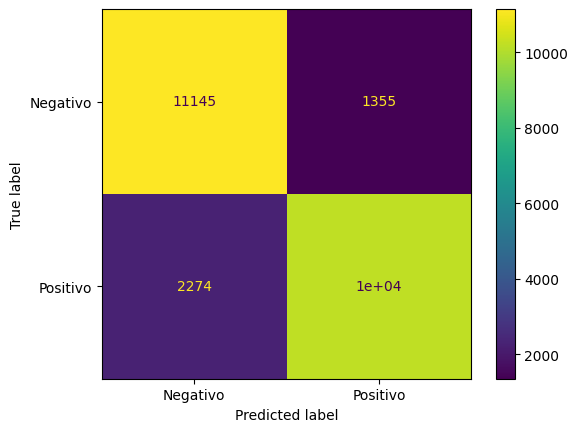

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Substitua 'model' pelo seu modelo final.
y_prob = model.predict(x_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
).plot()
plt.grid(False)
plt.show()


In [104]:
#MATRIZ DE CONFUSÃO E ANÁLISE DE ERROS

print("=" * 60)
print("RESUMO DO MODELO FINAL")
print("=" * 60)

final_model.summary()

print("\nNúmero de parâmetros:")
print(f"{final_model.count_params():,}")

RESUMO DO MODELO FINAL


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,693 (3.95 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 689,796 (2.63 MB)


Número de parâmetros:
344,897


In [105]:
#RESULTADOS DO TREINAMENTO

best_val_acc = max(
    history_final.history["val_accuracy"]
)

final_test_loss, final_test_acc = final_model.evaluate(
    x_test_final,
    y_test,
    verbose=0
)

print("=" * 60)
print("RESULTADOS")
print("=" * 60)

print(f"Melhor acurácia de validação: {best_val_acc:.4f}")
print(f"Acurácia no teste:             {final_test_acc:.4f}")
print(f"Loss no teste:                 {final_test_loss:.4f}")
print(f"Tempo de treinamento:          {tempo_final:.2f} s")

RESULTADOS
Melhor acurácia de validação: 0.8798
Acurácia no teste:             0.8690
Loss no teste:                 0.3291
Tempo de treinamento:          13.19 s


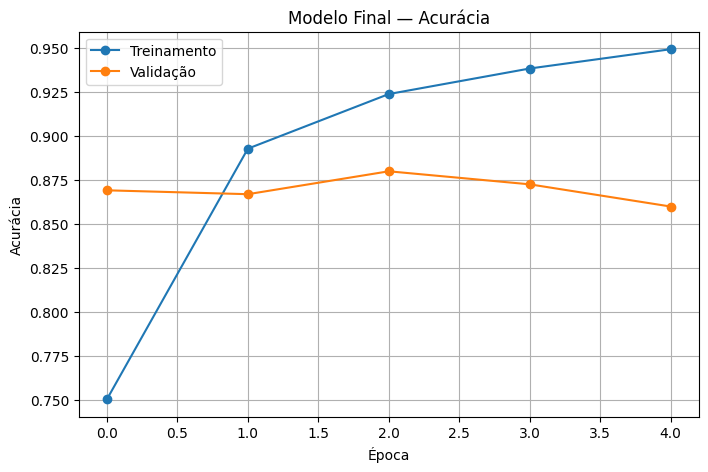

In [106]:
#CURVA DE ACURÁCIA

plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["accuracy"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    history_final.history["val_accuracy"],
    marker="o",
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Modelo Final — Acurácia")

plt.legend()
plt.grid(True)

plt.show()

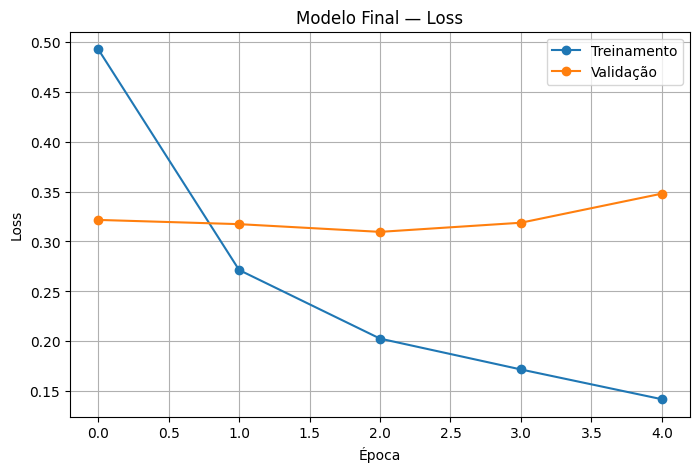

In [107]:
#CURVA DE LOSS

plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["loss"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    history_final.history["val_loss"],
    marker="o",
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Modelo Final — Loss")

plt.legend()
plt.grid(True)

plt.show()

In [108]:
#PREVISÕES DO MODELO FINAL

import numpy as np

y_prob = final_model.predict(
    x_test_final,
    verbose=0
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)


print("Primeiras probabilidades:")
print(y_prob[:10])

print("\nPrimeiras classes previstas:")
print(y_pred[:10])

print("\nPrimeiras classes verdadeiras:")
print(np.asarray(y_test)[:10])

Primeiras probabilidades:
[0.08135756 0.991687   0.675831   0.24376957 0.9984888  0.92260116
 0.979318   0.01167109 0.9889131  0.98912257]

Primeiras classes previstas:
[0 1 1 0 1 1 1 0 1 1]

Primeiras classes verdadeiras:
[0 1 1 0 1 1 1 0 0 1]


Matriz de confusão:
[[11044  1456]
 [ 1820 10680]]


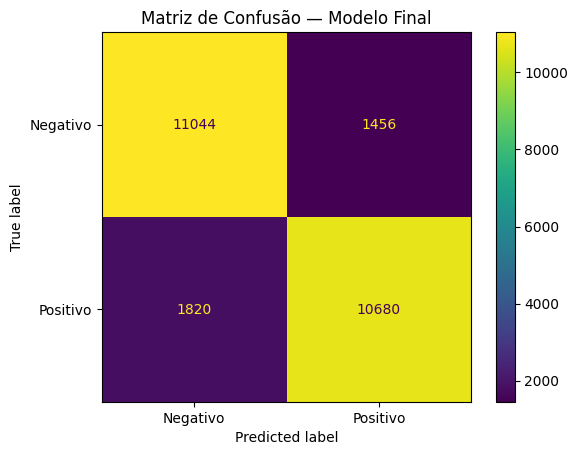

In [109]:
#MATRIZ DE CONFUSÃO

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de confusão:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

disp.plot()

plt.grid(False)
plt.title("Matriz de Confusão — Modelo Final")

plt.show()

In [110]:
#INTERPRETAÇÃO DA MATRIZ

TN, FP, FN, TP = cm.ravel()

print("=" * 50)
print("INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO")
print("=" * 50)

print(f"Verdadeiros Negativos (TN): {TN}")
print(f"Falsos Positivos   (FP):    {FP}")
print(f"Falsos Negativos   (FN):    {FN}")
print(f"Verdadeiros Positivos (TP): {TP}")

INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
Verdadeiros Negativos (TN): 11044
Falsos Positivos   (FP):    1456
Falsos Negativos   (FN):    1820
Verdadeiros Positivos (TP): 10680


In [111]:
#ANÁLISE DOS ERROS

total = len(y_test)

erros = np.sum(
    y_pred != np.asarray(y_test)
)

acertos = total - erros

print("=" * 50)
print("ANÁLISE DOS RESULTADOS")
print("=" * 50)

print(f"Total de exemplos: {total}")
print(f"Acertos:           {acertos}")
print(f"Erros:             {erros}")

print(f"Taxa de erro:      {erros / total:.4f}")

print(f"Taxa de acerto:    {acertos / total:.4f}")

ANÁLISE DOS RESULTADOS
Total de exemplos: 25000
Acertos:           21724
Erros:             3276
Taxa de erro:      0.1310
Taxa de acerto:    0.8690


In [112]:
#ÍNDICES DOS EXEMPLOS INCORRETOS

erros_idx = np.where(
    y_pred != np.asarray(y_test)
)[0]

print(f"Número total de erros: {len(erros_idx)}")

print("\nÍndices dos primeiros erros:")
print(erros_idx[:10])

Número total de erros: 3276

Índices dos primeiros erros:
[  8  17  22  55  66  75  80 100 101 115]


In [113]:
#RECUPERAR PALAVRAS DO IMDB

word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"


def decode_review(sequence):

    words = []

    for index in sequence:

        if index == 0:
            continue

        word = reverse_word_index.get(
            index,
            "<UNK>"
        )

        words.append(word)

    return " ".join(words)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [114]:
#MOSTRAR 5 ERROS

print("=" * 70)
print("EXEMPLOS CLASSIFICADOS INCORRETAMENTE")
print("=" * 70)

for i, idx in enumerate(erros_idx[:5], start=1):

    verdadeiro = int(
        np.asarray(y_test)[idx]
    )

    previsto = int(
        y_pred[idx]
    )

    probabilidade = y_prob[idx]

    texto = decode_review(
        X_test[idx]
    )

    print(f"\n{'=' * 70}")
    print(f"ERRO {i}")
    print(f"{'=' * 70}")

    print(f"Classe verdadeira: {verdadeiro}")
    print(f"Classe prevista:   {previsto}")
    print(f"Probabilidade:     {probabilidade:.4f}")

    print("\nTrecho da avaliação:")
    print(texto[:1000])

EXEMPLOS CLASSIFICADOS INCORRETAMENTE

ERRO 1
Classe verdadeira: 0
Classe prevista:   1
Probabilidade:     0.9889

Trecho da avaliação:
<START> hollywood had a long love affair with bogus <UNK> nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs <UNK> <UNK> and slapstick it's a truly crop of corn and pretty near <UNK> today it was nominated for its imaginative special effects which are almost <UNK> in this day and age <UNK> mainly of trick photography the only outstanding positive feature which survives is its beautiful color and clarity sad to say of the many films made in this genre few of them come up to alexander <UNK> original thief of <UNK> almost any other <UNK> nights film is superior to this one though it's a loser

ERRO 2
Classe verdadeira: 0
Classe prevista:   1
Probabilidade:     0.6132

Trecho da avaliação:
<START> ed <UNK> mitchell i

In [115]:
#TABELA DOS ERROS

erros_tabela = []

for idx in erros_idx[:10]:

    verdadeiro = int(
        np.asarray(y_test)[idx]
    )

    previsto = int(
        y_pred[idx]
    )

    probabilidade = y_prob[idx]

    erros_tabela.append({
        "Índice": idx,
        "Classe verdadeira": verdadeiro,
        "Classe prevista": previsto,
        "Probabilidade": round(
            float(probabilidade),
            4
        ),
        "Confiança": round(
            float(
                max(
                    probabilidade,
                    1 - probabilidade
                )
            ),
            4
        )
    })


erros_df = pd.DataFrame(
    erros_tabela
)

erros_df

,Índice,Classe verdadeira,Classe prevista,Probabilidade,Confiança
0,8,0,1,0.9889,0.9889
1,17,0,1,0.6132,0.6132
2,22,1,0,0.2750,0.7250
3,55,1,0,0.2355,0.7645
4,66,0,1,0.8472,0.8472
5,75,0,1,0.9565,0.9565
6,80,1,0,0.0926,0.9074
7,100,1,0,0.0554,0.9446
8,101,1,0,0.0156,0.9844
9,115,0,1,0.6480,0.6480


In [116]:
#CONFIANÇA NOS ERROS

confiancas = np.maximum(
    y_prob[erros_idx],
    1 - y_prob[erros_idx]
)

print(
    f"Confiança média nos erros: "
    f"{confiancas.mean():.4f}"
)

print(
    f"Maior confiança em um erro: "
    f"{confiancas.max():.4f}"
)

print(
    f"Menor confiança em um erro: "
    f"{confiancas.min():.4f}"
)

Confiança média nos erros: 0.7989
Maior confiança em um erro: 0.9995
Menor confiança em um erro: 0.5001


### Tarefa 18 — Análise de erros

Para pelo menos cinco erros, apresente:

- classe verdadeira;
- classe prevista;
- probabilidade prevista;
- trecho da avaliação.

Procure padrões como:

- negação (`not`, `never`);
- avaliações muito longas;
- ironia;
- vocabulário desconhecido;
- dependências de longo prazo;
- palavras ambíguas.

Depois responda: **os erros parecem estar associados à arquitetura, à representação dos dados ou à própria dificuldade da tarefa?**


# 18. Questões finais

1. Por que a ordem dos elementos é importante em dados sequenciais?
2. Qual é a função do estado oculto $a^{\langle t\rangle}$?
3. Por que os pesos são compartilhados entre os passos temporais?
4. O que é BPTT?
5. Por que ocorre vanishing gradient?
6. Para que serve gradient clipping?
7. Por que LSTM possui portas?
8. Qual é a função das portas reset e update da GRU?
9. Qual é a principal vantagem e a principal limitação de uma BRNN?
10. Por que `return_sequences=True` é necessário para empilhar RNNs?
11. Por que embeddings são preferíveis a one-hot em muitas aplicações de NLP?
12. Se duas arquiteturas possuem acurácia semelhante, como você escolheria entre elas para uma aplicação embarcada?
13. Compare RNN, CNN e Transformer quanto à forma de explorar dependências na sequência.


### Respostaqs para as Questões finais

1. Porque o significado ou a previsão pode depender da posição e do contexto dos elementos. A ordem de palavras, por exemplo, pode alterar o significado de uma frase.

2. Representar informações relevantes acumuladas ao longo da sequência e transmiti-las ao próximo passo temporal.

3. Para aplicar o mesmo mecanismo de transformação a diferentes posições da sequência, reduzindo o número de parâmetros e permitindo generalização ao longo do tempo.

4. É o Backpropagation Through Time, no qual a retropropagação percorre também as conexões temporais da RNN.

5. Porque a retropropagação envolve produtos sucessivos de fatores que podem ter magnitude menor que 1. Depois de muitos passos, o gradiente pode se aproximar de zero.

6. Para limitar a magnitude dos gradientes e reduzir problemas de exploding gradient.

7. Para controlar o que deve ser esquecido, armazenado/atualizado e disponibilizado como saída, facilitando a manutenção de informações relevantes por períodos maiores.

8. A reset gate controla quanto do estado anterior participa da construção da nova informação candidata. A update gate controla quanto do estado anterior é mantido versus quanto da nova informação é incorporado.

9. Vantagem: pode utilizar contexto dos dois sentidos da sequência. Limitação: precisa ter acesso ao contexto futuro, o que não é compatível com algumas aplicações online ou de tempo real.

10. Porque a próxima camada recorrente precisa receber a sequência completa de estados, preservando a dimensão temporal.

11. Porque são representações densas e normalmente de menor dimensão, aprendendo representações úteis das palavras em vez de utilizar vetores esparsos de dimensão igual ao vocabulário.

12. Comparar requisitos como número de parâmetros, memória, latência, consumo de energia, tempo de inferência e recursos disponíveis. A escolha depende das restrições da aplicação.

13.   
- RNN: processa sequencialmente e mantém um estado recorrente.
- CNN: utiliza filtros sobre janelas locais; camadas sucessivas podem aumentar o campo receptivo.
- Transformer: utiliza mecanismos de atenção para relacionar diferentes posições da sequência de forma direta, permitindo maior paralelização durante o treinamento.

# 19. Desafio opcional — modelo de linguagem

Nos slides, o modelo de linguagem é apresentado como um modelo que estima probabilidades de sequências. Para uma sequência de palavras, pela regra da cadeia:

$$
P(y^{\langle1\rangle},\ldots,y^{\langle T\rangle})
=\prod_{t=1}^{T}P(y^{\langle t\rangle}|y^{\langle1\rangle},\ldots,y^{\langle t-1\rangle}).
$$

A rede pode ser treinada para prever a próxima palavra.

### Desafio

Construa um pequeno modelo de linguagem em nível de palavra ou caractere:

1. construa o vocabulário;
2. crie pares `(entrada, próxima palavra)`;
3. treine uma RNN, GRU ou LSTM;
4. obtenha a distribuição da próxima palavra;
5. gere uma sequência iterativamente.

O fluxo conceitual é:

```text
entrada → RNN → probabilidades → próxima palavra
                     ↑              |
                     └──────────────┘
```

Para a geração, você pode terminar após um número fixo de passos ou ao encontrar `<EOS>`, conceito também apresentado na aula.


### Solução

Uma forma simples de resolver esse opcional pode ser construída a partir de sequências de tokens, em que cada entrada contém palavras anteriores e o alvo é a próxima palavra.

In [117]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

texto = "o modelo aprende padrões em sequências e usa o contexto para prever a próxima palavra"
tokens = texto.lower().split()

vocab = sorted(set(tokens))
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

ids = [word_to_id[w] for w in tokens]
X, y = [], []

window = 3
for i in range(len(ids) - window):
    X.append(ids[i:i+window])
    y.append(ids[i+window])

X = np.array(X)
y = np.array(y)

model_lm = keras.Sequential([
    keras.Input(shape=(window,)),
    layers.Embedding(input_dim=len(vocab), output_dim=16),
    layers.LSTM(32),
    layers.Dense(len(vocab), activation="softmax")
])

model_lm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_lm.fit(X, y, epochs=100, verbose=0)

Para gerar uma sequência, a previsão pode ser realimentada como entrada do próximo passo:

In [118]:
seed = [word_to_id[w] for w in ["o", "modelo", "aprende"]]

for _ in range(5):
    x = np.array(seed[-window:])[None, :]
    probs = model_lm.predict(x, verbose=0)[0]
    next_id = int(np.argmax(probs))
    seed.append(next_id)

print(" ".join(id_to_word[i] for i in seed))

o modelo aprende padrões em sequências sequências usa


O fluxo é: sequência de entrada -> RNN/LSTM -> distribuição de probabilidades -> próxima palavra -> realimentação.

# Entrega (não é um avaliação)

O notebook deverá apresentar, no mínimo:

- análise do IMDB;
- distribuição dos comprimentos;
- padding/truncamento;
- baseline;
- SimpleRNN;
- LSTM;
- GRU;
- comparação entre arquiteturas;
- experimento com `MAXLEN`;
- experimento com dimensão do embedding;
- modelo final;
- avaliação no teste;
- matriz de confusão;
- análise de erros;
- respostas às questões conceituais.

